# 01 — Data Understanding
This notebook loads all four bank marketing datasets, compares them, and explores the main dataset
(`bank-additional-full.csv`) that will be used throughout the project.

**Key questions answered here:**
- What does each dataset contain?
- How is the target variable distributed?
- How many unknown / missing values exist per feature?

In [8]:
import sys, warnings
from pathlib import Path

# Add project root so src/ is importable
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.config import RAW_DIR, CSV_SEP, TARGET_COL
from src.data_loader import load_dataset, summarize_dataset, compare_datasets

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
print("Project root:", PROJECT_ROOT)

Project root: /Users/muhammedsalah/coding_projects/python/bank_marketing_un_project


## 1 — Compare All Four Datasets
The bank marketing study provides four CSV files. We load them all and compare shapes, column counts, and positive rates.

In [9]:
dataset_paths = {
    "bank":                  RAW_DIR / "bank.csv",
    "bank-full":             RAW_DIR / "bank-full.csv",
    "bank-additional":       RAW_DIR / "bank-additional.csv",
    "bank-additional-full":  RAW_DIR / "bank-additional-full.csv",
}

comparison = compare_datasets(dataset_paths)
comparison


2026-05-17 03:41:38 | INFO     | src.data_loader | Loaded bank.csv — shape (4521, 17)
2026-05-17 03:41:38 | INFO     | src.data_loader | Loaded bank-full.csv — shape (45211, 17)
2026-05-17 03:41:38 | INFO     | src.data_loader | Loaded bank-additional.csv — shape (4119, 21)
2026-05-17 03:41:38 | INFO     | src.data_loader | Loaded bank-additional-full.csv — shape (41188, 21)


,name,rows,columns,yes_pct,no_pct,unknown_total,duplicate_rows
0,bank,4521,17,11.52,88.48,5254,0
1,bank-full,45211,17,11.70,88.30,52124,0
2,bank-additional,4119,21,10.95,89.05,1230,0
3,bank-additional-full,41188,21,11.27,88.73,12718,12


## 2 — Load & Summarise the Main Dataset
We use `bank-additional-full.csv` (41 188 rows, 21 columns) — the largest, most feature-rich version.

In [10]:
df = load_dataset(dataset_paths["bank-additional-full"])
print(f"Shape: {df.shape}")
df.head()

2026-05-17 03:41:38 | INFO     | src.data_loader | Loaded bank-additional-full.csv — shape (41188, 21)


Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [11]:
summary = summarize_dataset(df)
for k, v in summary.items():
    print(f"{k}:")
    if isinstance(v, pd.DataFrame):
        display(v)
    else:
        print(v, "\n")

shape:
(41188, 21) 

columns:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'] 

dtypes:
{'age': 'int64', 'job': 'str', 'marital': 'str', 'education': 'str', 'default': 'str', 'housing': 'str', 'loan': 'str', 'contact': 'str', 'month': 'str', 'day_of_week': 'str', 'duration': 'int64', 'campaign': 'int64', 'pdays': 'int64', 'previous': 'int64', 'poutcome': 'str', 'emp.var.rate': 'float64', 'cons.price.idx': 'float64', 'cons.conf.idx': 'float64', 'euribor3m': 'float64', 'nr.employed': 'float64', 'y': 'str'} 

missing_values:
{} 

duplicate_rows:
12 

target_distribution:
{'no': 36548, 'yes': 4640} 

unknown_counts:
{'job': 330, 'marital': 80, 'education': 1731, 'default': 8597, 'housing': 990, 'loan': 990} 



## 3 — Target Variable Distribution
The target `y` is highly imbalanced: ~88.7% "no" vs ~11.3% "yes". This drives our choice of **PR-AUC** as the primary metric rather than accuracy.

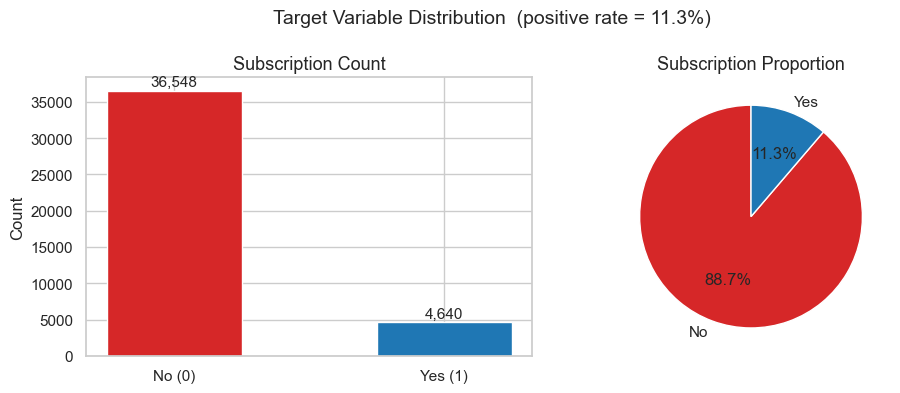


Class counts:
y
no     36548
yes     4640


In [12]:
counts = df[TARGET_COL].value_counts()
pos_rate = counts.get("yes", 0) / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(["No (0)", "Yes (1)"], [counts.get("no", 0), counts.get("yes", 0)],
            color=["#d62728", "#1f77b4"], edgecolor="white", width=0.5)
axes[0].set_title("Subscription Count", fontsize=13)
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, [counts.get("no", 0), counts.get("yes", 0)]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f"{val:,}", ha="center", va="bottom", fontsize=11)

# Pie chart
axes[1].pie([counts.get("no", 0), counts.get("yes", 0)],
            labels=["No", "Yes"], colors=["#d62728", "#1f77b4"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Subscription Proportion", fontsize=13)

plt.suptitle(f"Target Variable Distribution  (positive rate = {pos_rate:.1f}%)", fontsize=14)
plt.tight_layout()
plt.show()
print(f"\nClass counts:\n{counts.to_string()}")

## 4 — Unknown / Missing Value Summary
Several categorical features encode missing values as the string `"unknown"`. This cell quantifies them.

,unknown_count,pct_unknown
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


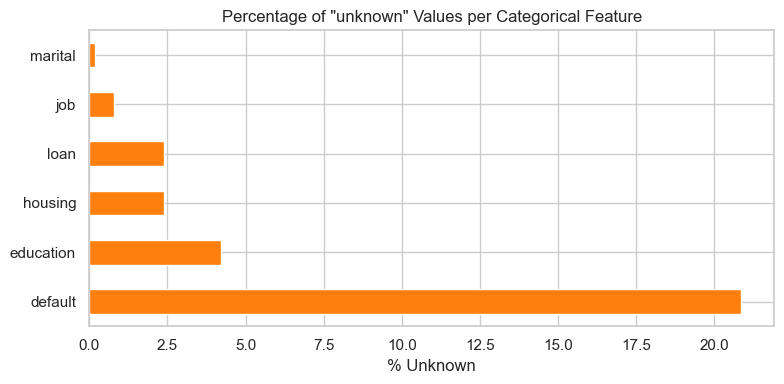

In [13]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
unknown_counts = {col: (df[col] == "unknown").sum() for col in cat_cols}
unknown_df = (
    pd.DataFrame.from_dict(unknown_counts, orient="index", columns=["unknown_count"])
    .assign(pct_unknown=lambda x: (x["unknown_count"] / len(df) * 100).round(2))
    .sort_values("unknown_count", ascending=False)
)
display(unknown_df[unknown_df["unknown_count"] > 0])

# Bar chart of unknown percentages
subset = unknown_df[unknown_df["unknown_count"] > 0]
fig, ax = plt.subplots(figsize=(8, 4))
subset["pct_unknown"].plot(kind="barh", ax=ax, color="#ff7f0e")
ax.set_xlabel("% Unknown")
ax.set_title('Percentage of "unknown" Values per Categorical Feature')
plt.tight_layout()
plt.show()

## 5 — Data Types & Descriptive Statistics

In [14]:
print("=== Data Types ===")
print(df.dtypes.to_string())
print(f"\n=== Descriptive Statistics (Numeric) ===")
display(df.describe().T.round(2))
print(f"\n=== Descriptive Statistics (Categorical) ===")
display(df.describe(include="object").T)

=== Data Types ===
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str

=== Descriptive Statistics (Numeric) ===


,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00
duration,41188.0,258.29,259.28,0.00,102.00,180.00,319.00,4918.00
campaign,41188.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
pdays,41188.0,962.48,186.91,0.00,999.00,999.00,999.00,999.00
previous,41188.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp.var.rate,41188.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,41188.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,41188.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,41188.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr.employed,41188.0,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10



=== Descriptive Statistics (Categorical) ===


,count,unique,top,freq
job,41188,12,admin.,10422
marital,41188,4,married,24928
education,41188,8,university.degree,12168
default,41188,3,no,32588
housing,41188,3,yes,21576
loan,41188,3,no,33950
contact,41188,2,cellular,26144
month,41188,10,may,13769
day_of_week,41188,5,thu,8623
poutcome,41188,3,nonexistent,35563


---
### ✅ Observations
- `bank-additional-full.csv` is the richest dataset: 41 188 rows × 21 columns + 4 macro-economic indicators absent from older files.
- The target `y` is **highly imbalanced** (~11.3% positive) → use **PR-AUC** not accuracy as primary metric.
- `duration` (last call length in seconds) perfectly predicts the outcome but is **only known after the call** — we deliberately exclude it from the Realistic Business Model.
- `default`, `job`, `education`, `marital`, `housing`, `loan` contain `"unknown"` values (handled via OneHotEncoder `handle_unknown='ignore'` in the pipeline).
- The four extra economic features (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`) are powerful predictors but correlate strongly with each other.